In [ ]:
from keras.models import Sequential
from keras.utils import get_file, to_categorical
from keras.layers import Embedding, Flatten, Dense, SpatialDropout1D, BatchNormalization, Dropout, SimpleRNN
from keras.layers import GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

from tensorflow.keras.preprocessing.text import Tokenizer

import os   # Модуль для работы с файловой системой

import glob # Вспомогательный модуль для работы с файловой системой
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Для работы с матрицей ошибок

import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
!pip install navec

In [ ]:
!wget https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar

--2025-09-15 16:17:54--  https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53012480 (51M) [application/x-tar]
Saving to: ‘navec_hudlit_v1_12B_500K_300d_100q.tar’

navec_hudlit_v1_12B 100%[===================>]  50.56M  15.1MB/s    in 5.3s    

2025-09-15 16:18:01 (9.53 MB/s) - ‘navec_hudlit_v1_12B_500K_300d_100q.tar’ saved [53012480/53012480]



In [ ]:
from navec import Navec
navec = Navec.load('navec_hudlit_v1_12B_500K_300d_100q.tar')

In [ ]:
data_path = get_file(
    "russian_literature.zip",
    "https://storage.yandexcloud.net/academy.ai/russian_literature.zip"
)

!unzip -qo "{data_path}" -d ./dataset

21547079/21547079 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
error:  cannot create ./dataset/poems/Blok/╨б╤В╨╕╤Е╨╛╤В╨▓╨╛╤А╨╡╨╜╨╕╤П 1897-1903 ╨│╨│, ╨╜╨╡ ╨▓╨╛╤И╨╡╨┤╤И╨╕╨╡ ╨▓ ╨╛╤Б╨╜╨╛╨▓╨╜╨╛╨╡ ╤Б╨╛╨▒╤А╨░╨╜╨╕╨╡.txt
        File name too long
error:  cannot create ./dataset/prose/Gogol/╨Я╨╛╨▓╨╡╤Б╤В╤М ╨╛ ╤В╨╛╨╝, ╨║╨░╨║ ╨┐╨╛╤Б╤Б╨╛╤А╨╕╨╗╤Б╤П ╨Ш╨▓╨░╨╜ ╨Ш╨▓╨░╨╜╨╛╨▓╨╕╤З ╤Б ╨Ш╨▓╨░╨╜╨╛╨╝ ╨Э╨╕╨║╨╕╤Д╨╛╤А╨╛╨▓╨╕╤З╨╡╨╝.txt
        File name too long
error:  cannot create ./dataset/publicism/Tolstoy/╨Ф╨╛╨║╨╗╨░╨┤, ╨┐╤А╨╕╨│╨╛╤В╨╛╨▓╨╗╨╡╨╜╨╜╤Л╨╣ ╨┤╨╗╤П ╨║╨╛╨╜╨│╤А╨╡╤Б╤Б╨░ ╨╛ ╨╝╨╕╤А╨╡ ╨▓ ╨б╤В╨╛╨║╨│╨╛╨╗╤М╨╝╨╡.txt
        File name too long
error:  cannot create ./dataset/publicism/Tolstoy/╨Я╨╛╤З╨╡╨╝╤Г ╤Е╤А╨╕╤Б╤В╨╕╨░╨╜╤Б╨║╨╕╨╡ ╨╜╨░╤А╨╛╨┤╤Л ╨▓╨╛╨╛╨▒╤Й╨╡ ╨╕ ╨▓ ╨╛╤Б╨╛╨▒╨╡╨╜╨╜╨╛╤Б╤В╨╕ ╤А╤Г╤Б╤Б╨║╨╕╨╣ ╨╜╨░╤Е╨╛╨┤╤П╤В╤Б╤П ╤В╨╡╨┐╨╡╤А╤М ╨▓ ╨▒╨╡╨┤╤Б╤В╨▓╨╡╨╜╨╜╨╛╨╝ ╨┐╨╛╨╗╨╛╨╢╨╡╨╜╨╕╨╕.txt
        File name too long


In [ ]:
FILE_DIR_POEMS = './dataset/poems'
file_list_poems = os.listdir(FILE_DIR_POEMS)
print("Поэты:")
print(file_list_poems)

Поэты:
['Blok', 'Lermontov', 'Nekrasov', 'Pushkin']


In [ ]:
FILE_DIR_PROSE = './dataset/prose'
file_list_prose = os.listdir(FILE_DIR_PROSE)
print("Прозаики:")
print(file_list_prose)

Прозаики:
['Blok', 'Lermontov', 'Dostoevsky', 'Bryusov', 'Gogol', 'Gorky', 'Turgenev', 'Chekhov', 'Pushkin', 'Herzen', 'Tolstoy']


In [ ]:
CLASS_LIST = list(set(file_list_poems + file_list_prose))
print("Общий список писателей:")
print(CLASS_LIST)

Общий список писателей:
['Dostoevsky', 'Nekrasov', 'Gorky', 'Tolstoy', 'Pushkin', 'Bryusov', 'Herzen', 'Turgenev', 'Lermontov', 'Blok', 'Gogol', 'Chekhov']


In [ ]:
CLASS_LIST = ['Turgenev', 'Tolstoy', 'Pushkin', 'Chekhov']
print("Выбранный список писателей:")
print(CLASS_LIST)

Выбранный список писателей:
['Turgenev', 'Tolstoy', 'Pushkin', 'Chekhov']


In [ ]:
all_texts = {} # Собираем в словарь весь датасет

for author in CLASS_LIST:
    all_texts[author] = '' # Инициализируем пустой строкой новый ключ словаря
    for path in glob.glob('./dataset/prose/{}/*.txt'.format(author)) +  glob.glob('./dataset/poems/{}/*.txt'.format(author)): # Поиск файлов по шаблону
        with open(f'{path}', 'r', errors='ignore') as f: # игнорируем ошибки (например символы из другой кодировки)
            # Загрузка содержимого файла в строку
            text = f.read()

        all_texts[author]  += ' ' + text.replace('\n', ' ') # Заменяем символ перехода на новую строку пробелом

In [ ]:
embedding_dim = 300    # размерность векторов эмбединга (300d в имени эмбединга)
max_words = 15000      # Количество слов, рассматриваемых как признаки

# Используется встроенный в Keras токенизатор для разбиения текста и построения частотного словаря
tokenizer = Tokenizer(num_words=max_words,
                      filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                      lower=True, split=' ', char_level=False)


# Построение частотного словаря по текстам
tokenizer.fit_on_texts(all_texts.values())

In [ ]:
seq_train = tokenizer.texts_to_sequences(all_texts.values())

In [ ]:
# используем генератор цикла для получения длины текстов по каждому автору
total = sum(len(i) for i in seq_train)
print(f'Датасет состоит из {total} слов')

print('Общая выборка по писателям (по словам):')
mean_list = np.array([])
for author in CLASS_LIST:
    cls = CLASS_LIST.index(author)
    print(f'{author} - {len(seq_train[cls])} слов, доля в общей базе: {len(seq_train[cls])/total*100 :.2f}%')
    mean_list = np.append(mean_list, len(seq_train[cls]))

print('Среднее значение слов: ', np.round(mean_list.mean()))
print('Медианное значение слов: ', np.median(mean_list))


median = int(np.median(mean_list)) # Зафиксировали медианное значение
CLASS_LIST_BALANCE = [] # Сбалансированный набор меток
seq_train_balance = []
for author in CLASS_LIST:
    cls = CLASS_LIST.index(author)
    if len(seq_train[cls]) > median * 0.6:
      seq_train_balance.append(seq_train[cls][:median])
      CLASS_LIST_BALANCE.append(author)

Датасет состоит из 1981325 слов
Общая выборка по писателям (по словам):
Turgenev - 307677 слов, доля в общей базе: 15.53%
Tolstoy - 1257947 слов, доля в общей базе: 63.49%
Pushkin - 170149 слов, доля в общей базе: 8.59%
Chekhov - 245552 слов, доля в общей базе: 12.39%
Среднее значение слов:  495331.0
Медианное значение слов:  276614.5


In [ ]:
total = sum(len(i) for i in seq_train_balance)

print('Сбалансированная выборка по писателям (по словам):')
mean_list_balance = np.array([])
for author in CLASS_LIST_BALANCE:
    cls = CLASS_LIST_BALANCE.index(author)
    print(f'{author} - {len(seq_train_balance[cls])} слов, доля в общей базе: {len(seq_train_balance[cls])/total*100 :.2f}%')
    mean_list_balance = np.append(mean_list_balance, len(seq_train_balance[cls]))

print('Среднее значение слов: ', np.round(mean_list_balance.mean()))
print('Медианное значение слов: ', np.median(mean_list_balance))

Сбалансированная выборка по писателям (по словам):
Turgenev - 276614 слов, доля в общей базе: 28.55%
Tolstoy - 276614 слов, доля в общей базе: 28.55%
Pushkin - 170149 слов, доля в общей базе: 17.56%
Chekhov - 245552 слов, доля в общей базе: 25.34%
Среднее значение слов:  242232.0
Медианное значение слов:  261083.0


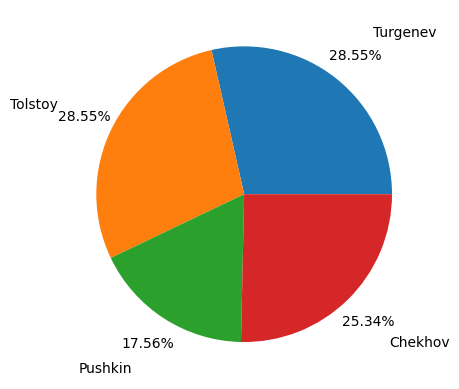

In [ ]:
fig, ax = plt.subplots()
ax.pie([len(i) for i in seq_train_balance],  # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST_BALANCE,            # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

In [ ]:
# используем генератор цикла для получения длины текстов по каждому автору
total = sum(len(i) for i in seq_train_balance)
print(f'Датасет состоит из {total} слов')

Датасет состоит из 968929 слов


In [ ]:
print('Общая выборка по писателям (по словам):')
mean_list = np.array([])
for author in CLASS_LIST_BALANCE:
    cls = CLASS_LIST_BALANCE.index(author)
    print(f'{author} - {len(seq_train_balance[cls])} слов, доля в общей базе: {len(seq_train_balance[cls])/total*100 :.2f}%')
    mean_list = np.append(mean_list, len(seq_train_balance[cls]))

print('Среднее значение слов: ', np.round(mean_list.mean()))
print('Медианное значение слов: ', np.median(mean_list))

Общая выборка по писателям (по словам):
Turgenev - 276614 слов, доля в общей базе: 28.55%
Tolstoy - 276614 слов, доля в общей базе: 28.55%
Pushkin - 170149 слов, доля в общей базе: 17.56%
Chekhov - 245552 слов, доля в общей базе: 25.34%
Среднее значение слов:  242232.0
Медианное значение слов:  261083.0


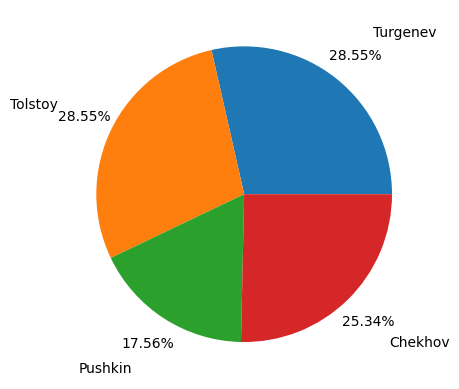

In [ ]:
fig, ax = plt.subplots()
ax.pie([len(i) for i in seq_train_balance], # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST_BALANCE,                    # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

In [ ]:
import numpy as np
from keras.utils import to_categorical

WIN_SIZE = 1000   # Ширина окна в токенах
WIN_STEP = 100    # Шаг окна в токенах

# Функция разбиения последовательности на отрезки скользящим окном
def seq_split(sequence, win_size, step):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, step)]

def seq_vectorize(
    seq_list,   # Последовательность
    test_split, # Доля на тестовую выборку (10%)
    class_list, # Список классов
    win_size,   # Ширина скользящего окна
    step        # Шаг скользящего окна
):

    # Списки для результирующих данных
    x_train, y_train, x_val, y_val, x_test, y_test =  [], [], [], [], [], []

    for class_item in class_list:
        # Получаем индекс класса
        cls = class_list.index(class_item)

        # Общее количество элементов в классе
        total_samples = len(seq_list[cls])

        # Пороги для разбивки
        train_val_split = int(total_samples * 0.8)  # 80% для обучающей и проверочной
        val_test_split = int(total_samples * 0.9)   # 10% для проверочной и 10% для тестовой

        # Разбиваем последовательность токенов класса на отрезки
        vectors_train = seq_split(seq_list[cls][:train_val_split], win_size, step)  # Обучающая выборка
        vectors_val = seq_split(seq_list[cls][train_val_split:val_test_split], win_size, step)  # Проверочная выборка
        vectors_test = seq_split(seq_list[cls][val_test_split:], win_size, step)  # Тестовая выборка

        # Добавляем отрезки в выборку
        x_train += vectors_train
        x_val += vectors_val
        x_test += vectors_test

        # Генерируем метки
        y_train += [to_categorical(cls, len(class_list))] * len(vectors_train)
        y_val += [to_categorical(cls, len(class_list))] * len(vectors_val)
        y_test += [to_categorical(cls, len(class_list))] * len(vectors_test)

    # Возвращаем результаты как numpy-массивы
    return np.array(x_train), np.array(y_train), np.array(x_val), np.array(y_val), np.array(x_test), np.array(y_test)

In [ ]:
x_train, y_train, x_val, y_val, x_test, y_test = seq_vectorize(seq_train_balance, 0.1, CLASS_LIST_BALANCE, WIN_SIZE, WIN_STEP)

In [ ]:
print(f'Форма входных данных для обучающей выборки: {x_train.shape}')
print(f'Форма выходных данных (меток) для обучающей выборки: {y_train.shape}')

Форма входных данных для обучающей выборки: (7713, 1000)
Форма выходных данных (меток) для обучающей выборки: (7713, 4)


In [ ]:
print(f'Форма входных данных для тестовой выборки: {x_val.shape}')
print(f'Форма выходных данных (меток) для тестовой выборки: {y_val.shape}')

Форма входных данных для тестовой выборки: (931, 1000)
Форма выходных данных (меток) для тестовой выборки: (931, 4)


In [ ]:
print(f'Форма входных данных для тестовой выборки: {x_test.shape}')
print(f'Форма выходных данных (меток) для тестовой выборки: {y_test.shape}')

Форма входных данных для тестовой выборки: (931, 1000)
Форма выходных данных (меток) для тестовой выборки: (931, 4)


In [ ]:
# Вывод графиков точности и ошибки
def show_plot(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('График процесса обучения модели: '+title)
    ax1.plot(history.history['accuracy'],
               label='График точности на обучающей выборке')
    ax1.plot(history.history['val_accuracy'],
               label='График точности на проверочной выборке')
    ax1.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('График точности')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающей выборке')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочной выборке')
    ax2.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()

# Функция вывода предсказанных значений
def show_confusion_matrix(y_true, y_pred, class_labels):
    # Матрица ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, 3)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(f'Матрица ошибок', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Убираем ненужную цветовую шкалу
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси
    plt.show()


    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))

In [ ]:
def loadEmbedding():
    word_index = tokenizer.word_index
    embeddings_index = navec

    embedding_matrix = np.zeros((max_words, embedding_dim))
    for word, i in word_index.items():
        if i < max_words:
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector

    return embedding_matrix

In [ ]:
from keras.regularizers import l2
model_MIX = Sequential()


embedding_layer = Embedding(max_words, embedding_dim, input_length=WIN_SIZE, weights=loadEmbedding())
model_MIX.add(embedding_layer)
model_MIX.add(SpatialDropout1D(0.3))
model_MIX.add(BatchNormalization())

embedding_layer.trainable = False

# Два двунаправленных рекуррентных слоя LSTM
model_MIX.add(Bidirectional(LSTM(32, return_sequences=True)))
model_MIX.add(Bidirectional(LSTM(32, return_sequences=True)))
model_MIX.add(Dropout(0.3))
model_MIX.add(BatchNormalization())

# Два рекуррентных слоя GRU
model_MIX.add(GRU(64, return_sequences=True, reset_after=True))
model_MIX.add(GRU(64, reset_after=True))
model_MIX.add(Dropout(0.3))
model_MIX.add(BatchNormalization())

# Дополнительный полносвязный слой
model_MIX.add(Dense(100, activation='relu', kernel_regularizer=l2(0.01)))
model_MIX.add(Dropout(0.3))
model_MIX.add(BatchNormalization())
model_MIX.add(Dense(len(CLASS_LIST_BALANCE), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=2)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, verbose=1, restore_best_weights=True)

In [ ]:
model_MIX.layers[0].trainable = False

In [ ]:
model_MIX.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_mix = model_MIX.fit(x_train, y_train, epochs=50, batch_size=128, validation_data=(x_val, y_val),  callbacks=[checkpoint, early_stopping])

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.2812 - loss: 2.5142
Epoch 1: val_accuracy improved from -inf to 0.26423, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 32s 269ms/step - accuracy: 0.2814 - loss: 2.5122 - val_accuracy: 0.2642 - val_loss: 2.0304
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.3321 - loss: 2.0985
Epoch 2: val_accuracy improved from 0.26423 to 0.34801, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 265ms/step - accuracy: 0.3324 - loss: 2.0974 - val_accuracy: 0.3480 - val_loss: 1.8550
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.4037 - loss: 1.8248
Epoch 3: val_accuracy improved from 0.34801 to 0.45435, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 258ms/step - accuracy: 0.4041 - loss: 1.8237 - val_accuracy: 0.4544 - val_loss: 1.6198
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.5018 - loss: 1.5487
Epoch 4: val_accuracy improved from 0.45435 to 0.51128, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 241ms/step - accuracy: 0.5018 - loss: 1.5485 - val_accuracy: 0.5113 - val_loss: 1.3963
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.4857 - loss: 1.4812
Epoch 5: val_accuracy did not improve from 0.51128
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 239ms/step - accuracy: 0.4857 - loss: 1.4808 - val_accuracy: 0.4329 - val_loss: 1.5474
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.5316 - loss: 1.3342
Epoch 6: val_accuracy did not improve from 0.51128
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 240ms/step - accuracy: 0.5316 - loss: 1.3340 - val_accuracy: 0.5059 - val_loss: 1.3253
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.5719 - loss: 1.1934
Epoch 7: val_accuracy improved from 0.51128 to 0.54887, saving model to best_model.h5


...

61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 254ms/step - accuracy: 0.5950 - loss: 1.0902 - val_accuracy: 0.5994 - val_loss: 1.0499
Epoch 10/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7919 - loss: 0.6854
Epoch 10: val_accuracy improved from 0.59936 to 0.82385, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 243ms/step - accuracy: 0.7922 - loss: 0.6843 - val_accuracy: 0.8238 - val_loss: 0.5727
Epoch 11/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8621 - loss: 0.4542
Epoch 11: val_accuracy did not improve from 0.82385
61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 241ms/step - accuracy: 0.8623 - loss: 0.4538 - val_accuracy: 0.8067 - val_loss: 0.5917
Epoch 12/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9019 - loss: 0.3452
Epoch 12: val_accuracy improved from 0.82385 to 0.96133, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - accuracy: 0.9021 - loss: 0.3448 - val_accuracy: 0.9613 - val_loss: 0.1710
Epoch 13/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9248 - loss: 0.2697
Epoch 13: val_accuracy did not improve from 0.96133
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 251ms/step - accuracy: 0.9250 - loss: 0.2693 - val_accuracy: 0.9044 - val_loss: 0.3047
Epoch 14/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9461 - loss: 0.2021
Epoch 14: val_accuracy did not improve from 0.96133
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - accuracy: 0.9462 - loss: 0.2018 - val_accuracy: 0.9474 - val_loss: 0.1736
Epoch 15/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9567 - loss: 0.1569
Epoch 15: val_accuracy improved from 0.96133 to 0.97530, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.9568 - loss: 0.1568 - val_accuracy: 0.9753 - val_loss: 0.0965
Epoch 16/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9718 - loss: 0.1177
Epoch 16: val_accuracy did not improve from 0.97530
61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - accuracy: 0.9717 - loss: 0.1178 - val_accuracy: 0.9721 - val_loss: 0.1092
Epoch 17/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9704 - loss: 0.1120
Epoch 17: val_accuracy did not improve from 0.97530
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - accuracy: 0.9705 - loss: 0.1119 - val_accuracy: 0.9517 - val_loss: 0.1560
Epoch 18/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9724 - loss: 0.0978
Epoch 18: val_accuracy did not improve from 0.97530
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - accuracy: 0.9724 - loss: 0.0978 - val_accuracy: 0.9603 - val_loss: 0.1391
Epoch 19/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9798 - loss: 0.0729
Epoch 19: val_accuracy d

61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - accuracy: 0.9888 - loss: 0.0443 - val_accuracy: 0.9979 - val_loss: 0.0179
Epoch 25/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9882 - loss: 0.0436
Epoch 25: val_accuracy did not improve from 0.99785
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 253ms/step - accuracy: 0.9882 - loss: 0.0435 - val_accuracy: 0.9678 - val_loss: 0.0980
Epoch 26/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9898 - loss: 0.0388
Epoch 26: val_accuracy did not improve from 0.99785
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.9898 - loss: 0.0386 - val_accuracy: 0.9968 - val_loss: 0.0202
Epoch 27/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9935 - loss: 0.0268
Epoch 27: val_accuracy did not improve from 0.99785
61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 254ms/step - accuracy: 0.9934 - loss: 0.0269 - val_accuracy: 0.9334 - val_loss: 0.2395
Epoch 28/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9850 - loss: 0.0501
Epoch 28: val_accuracy d

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step


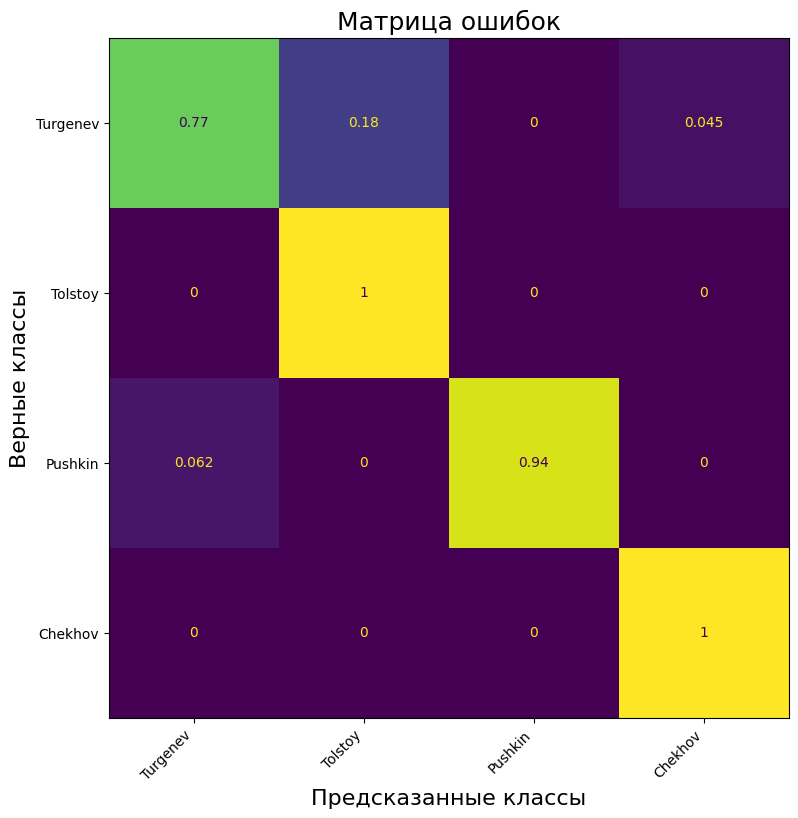


Средняя точность распознавания:  93%


In [ ]:
y_pred_mix = model_MIX.predict(x_test)
show_confusion_matrix(y_test, y_pred_mix, CLASS_LIST_BALANCE)

In [ ]:
#стих собственного сочинения
own_text = 'Волшебные миры над нами, пока веет запахом летним, На небосводе зависли огнями, и смотрю я на склон. Кругом парят облака, таинственно встали деревья, Дневная спала жара, все будто видеофон. Гуляет тихо туман, он окутал подножие склона, «Однажды ступал тут» - подумал вдруг я, Был без страха устремлен в далекие годы, Где менялась с погода дуновением Весна. Пространство предстало безмерным, раньше было одно, «Все знакомое было знакомым» - все думал я глядя на склон. Я, смотря на часы, видел время. Мне шепот странствий твердит, Что однажды туман тот рассею, легким движением руки. Меня тянет спуститься по склону, оглядеть, что было спрятано там, Но вдохнув свежестью летней, я взглянул вверх и кто-то сказал: «Однажды сомкнуться миры, все миры где будем когда-то, Тот туман, что у подножия - быль, от глаз что не была спрятана.»'

In [ ]:
own_text

'Волшебные миры над нами, пока веет запахом летним, На небосводе зависли огнями, и смотрю я на склон. Кругом парят облака, таинственно встали деревья, Дневная спала жара, все будто видеофон. Гуляет тихо туман, он окутал подножие склона, «Однажды ступал тут» - подумал вдруг я, Был без страха устремлен в далекие годы, Где менялась с погода дуновением Весна. Пространство предстало безмерным, раньше было одно, «Все знакомое было знакомым» - все думал я глядя на склон. Я, смотря на часы, видел время. Мне шепот странствий твердит, Что однажды туман тот рассею, легким движением руки. Меня тянет спуститься по склону, оглядеть, что было спрятано там, Но вдохнув свежестью летней, я взглянул вверх и кто-то сказал: «Однажды сомкнуться миры, все миры где будем когда-то, Тот туман, что у подножия - быль, от глаз что не была спрятана.»'

In [ ]:
import numpy as np
from keras.preprocessing.sequence import pad_sequences

# Функция для предобработки текста
def preprocess_text(text):

    tokens = tokenizer.texts_to_sequences([text])
    return pad_sequences(tokens, maxlen=WIN_SIZE)

# Подготовка текста
processed_text = preprocess_text(own_text)

# Получаем вероятности для каждого класса
predictions = model_MIX.predict(processed_text)

# Получаем индекс класса с наивысшей вероятностью
predicted_class_index = np.argmax(predictions, axis=1)[0]

# Получаем предсказанный класс по индексу
predicted_class = CLASS_LIST_BALANCE[predicted_class_index]

# Получаем вероятности принадлежности к классам
probabilities = predictions[0]

# Выводим предсказанный класс и соответствующие вероятности
print(f"Предсказанный класс: {predicted_class}")
print("Вероятности принадлежности к классам:")
for class_name, probability in zip(CLASS_LIST_BALANCE, probabilities):
    print(f"{class_name}: {probability:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Предсказанный класс: Tolstoy
Вероятности принадлежности к классам:
Turgenev: 0.0337
Tolstoy: 0.9652
Pushkin: 0.0002
Chekhov: 0.0009
